# Student Performance Factors Capstone Project

## Predicting Exam Performance from Academic, Behavioral, and Environmental Factors

This project analyzes the factors that influence student academic performance and builds predictive models to estimate future academic outcomes based on current student characteristics.


**OVERVIEW**

In this application, you will explore a dataset from Kaggle [here](https://raw.githubusercontent.com/ninadpatilr-jpg/capstone-student-grade/refs/heads/main/data/StudentPerformanceFactors.csv). This dataset contains information on 6k+ students. Goal is not only to predict grades but to translate findings into actionable recommendations for schools, educators, and policymakers.


### CRISP-DM Framework

<center>
    <img src = ./../images/crisp.png width = 25%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked to identify what influences student's performance. Educational institutions often need early signals that student performance may be affected by study habits, attendance, access to resources, or home environment. This project analyzes those factors and builds predictive models for **Exam_Score**. However, decisions about interventions are often made based on assumptions rather than evidence.

### Core questions
1. Which features show the strongest relationship with exam performance?
2. Which student and school factors are most useful for predicting **Exam_Score**?
3. What practical recommendations follow from the analysis?

### Primary evaluation metric
**MAE (Mean Absolute Error)** is treated as the primary business-facing metric because it keeps the error in exam-score points, which is easier to explain to a nontechnical audience. RMSE and R² are reported as supporting metrics.

In [171]:

# Run this first if your environment is missing dependencies.
# Recommended Python version: 3.11 or 3.12

import sys
import subprocess
import pkgutil

required_packages = {
    "numpy": "numpy>=1.26,<3.0",
    "pandas": "pandas>=2.2,<3.0",
    "matplotlib": "matplotlib>=3.8,<4.0",
    "seaborn": "seaborn>=0.13,<1.0",
    "scipy": "scipy>=1.11,<2.0",
    "sklearn": "scikit-learn>=1.4,<2.0",
    "jupyter": "jupyterlab>=4.0",
    "ipykernel": "ipykernel>=6.0",
    "nbformat": "nbformat>=5.10",
    "nbconvert": "nbconvert>=7.16",
}

missing_specs = [spec for module, spec in required_packages.items() if pkgutil.find_loader(module) is None]

if missing_specs:
    print("Installing missing packages...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"])
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + missing_specs)
else:
    print("All required packages are already installed.")

print(f"Python executable: {sys.executable}")


All required packages are already installed.
Python executable: /opt/anaconda3/bin/python


In [172]:

# Import libraries and configure notebook defaults.

# Core imports
import warnings
import time
import joblib
import math
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

### In this project, Using the CRISP-DM framework we will analyze a dataset to determine the key factors that drive Student's Performance. 
- **First clean and process the data to ensure accuracy and reliability**
- **Then, we will apply exploratory data analysis (EDA) and statistical modeling techniques to uncover trends in vehicle pricing.**
- **Identify the most influential factors affecting student grades**
- **Distinguish strong predictors from weak or commonly assumed factors**
- **Provide early indicators of academic risk**
- **Deliver data-driven recommendations for performance improvement**

Student academic performance is often discussed, but the drivers behind it are not always clearly understood. This capstone project will provide an actionable insights backed by data

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.
Will follow below steps:

- Identifying the variables (features) included in the dataset.
- Understanding the data types of each variable.
- Checking for missing values or inconsistencies.
- Exploring summary statistics to identify patterns or potential outliers.

## 1. Load the data

In [173]:
# Lets begin with loading this dataset. I have already downloaded the dataset and placed it in the data folder. 
# You can download the dataset from here: https://www.kaggle.com/datasets/ayeshaseherr/student-performance

df_student_raw = pd.read_csv("./../data/StudentPerformanceFactors.csv")
print("Shape:", df_student_raw.shape)
df_student_raw.head()

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 2. Data cleaning and validation

This section prepares the raw file for analysis by:
- standardizing column names
- removing duplicate rows if they exist
- checking missing values
- validating numeric and categorical feature groups
- confirming the target variable `exam_score`

In [174]:

# Normalize column names, remove duplicates, and profile data quality to create a clean working copy.

df_student = df_student_raw.copy()
df_student.columns = [
    column.strip().lower().replace(" ", "_").replace("/", "_").replace("-", "_")
    for column in df_student.columns
]

# Remove duplicates.
rows_before = len(df_student)
df_student = df_student.drop_duplicates().reset_index(drop=True)
rows_after = len(df_student)

# Quality summary.
quality_summary = pd.DataFrame({
    "dtype": df_student.dtypes.astype(str),
    "missing_values": df_student.isna().sum(),
    "missing_pct": (df_student.isna().mean() * 100).round(2),
    "unique_values": df_student.nunique(),
}).sort_values(["missing_values", "unique_values"], ascending=[False, False])

print(f"{rows_before - rows_after}, duplicate rows removed.")
print(f"Working shape: {df_student.shape}")
quality_summary

0, duplicate rows removed.
Working shape: (6607, 20)


,dtype,missing_values,missing_pct,unique_values
parental_education_level,object,90,1.36,3
teacher_quality,object,78,1.18,3
distance_from_home,object,67,1.01,3
previous_scores,int64,0,0.00,51
exam_score,int64,0,0.00,45
hours_studied,int64,0,0.00,41
attendance,int64,0,0.00,41
tutoring_sessions,int64,0,0.00,9
sleep_hours,int64,0,0.00,7
physical_activity,int64,0,0.00,7


In [175]:

# Coerce numeric types and split numeric vs categorical predictors.

for column in df_student.columns:
    if df_student[column].dtype == "object":
        converted = pd.to_numeric(df_student[column], errors="ignore")
        df_student[column] = converted

numeric_features = df_student.select_dtypes(include=np.number).columns.tolist()
if "exam_score" in numeric_features:
    numeric_features.remove("exam_score")

categorical_features = [column for column in df_student.columns if column not in numeric_features + ["exam_score"]]

print("Numeric predictors:", numeric_features)
print("Categorical predictors:", categorical_features)

Numeric predictors: ['hours_studied', 'attendance', 'sleep_hours', 'previous_scores', 'tutoring_sessions', 'physical_activity']
Categorical predictors: ['parental_involvement', 'access_to_resources', 'extracurricular_activities', 'motivation_level', 'internet_access', 'family_income', 'teacher_quality', 'school_type', 'peer_influence', 'learning_disabilities', 'parental_education_level', 'distance_from_home', 'gender']


## 3. Descriptive statistics

In [176]:
# Summarize numeric feature distributions.

summary_numeric = df_student.select_dtypes(include=np.number).describe().transpose()
summary_numeric

,count,mean,std,min,25%,50%,75%,max
hours_studied,"6,607.00",19.98,5.99,1.00,16.00,20.00,24.00,44.00
attendance,"6,607.00",79.98,11.55,60.00,70.00,80.00,90.00,100.00
sleep_hours,"6,607.00",7.03,1.47,4.00,6.00,7.00,8.00,10.00
previous_scores,"6,607.00",75.07,14.40,50.00,63.00,75.00,88.00,100.00
tutoring_sessions,"6,607.00",1.49,1.23,0.00,1.00,1.00,2.00,8.00
physical_activity,"6,607.00",2.97,1.03,0.00,2.00,3.00,4.00,6.00
exam_score,"6,607.00",67.24,3.89,55.00,65.00,67.00,69.00,101.00


In [177]:
# Inspect categorical value counts.

category_summaries = {}
for column in categorical_features:
    category_summaries[column] = df_student[column].value_counts(dropna=False)

category_summaries

{'parental_involvement': parental_involvement
 Medium    3362
 High      1908
 Low       1337
 Name: count, dtype: int64,
 'access_to_resources': access_to_resources
 Medium    3319
 High      1975
 Low       1313
 Name: count, dtype: int64,
 'extracurricular_activities': extracurricular_activities
 Yes    3938
 No     2669
 Name: count, dtype: int64,
 'motivation_level': motivation_level
 Medium    3351
 Low       1937
 High      1319
 Name: count, dtype: int64,
 'internet_access': internet_access
 Yes    6108
 No      499
 Name: count, dtype: int64,
 'family_income': family_income
 Low       2672
 Medium    2666
 High      1269
 Name: count, dtype: int64,
 'teacher_quality': teacher_quality
 Medium    3925
 High      1947
 Low        657
 NaN         78
 Name: count, dtype: int64,
 'school_type': school_type
 Public     4598
 Private    2009
 Name: count, dtype: int64,
 'peer_influence': peer_influence
 Positive    2638
 Neutral     2592
 Negative    1377
 Name: count, dtype: int64,


## 4. Inferential statistics
Applied inferential analysis to move beyond descriptive statistics.  
- Measured numeric feature relationships with `exam_score` using correlation tests.  
- Evaluated categorical feature impact on `exam_score` using group comparison tests.

These tests show association, not causation, and are used to prioritize variables for modeling.

In [178]:
# Numeric-feature correlation test against exam_score.
correlation_results = []
for column in numeric_features:
    subset = df_student[[column, "exam_score"]].dropna()
    if subset[column].nunique() > 1:
        corr, p_value = stats.pearsonr(subset[column], subset["exam_score"])
        correlation_results.append({
            "feature": column,
            "importance": corr,
            "p_value": p_value,
            "abs_r": abs(corr),
        })

correlation_results_df = pd.DataFrame(correlation_results).sort_values("abs_r", ascending=False)
correlation_results_df

,feature,importance,p_value,abs_r
1,attendance,0.58,0.00,0.58
0,hours_studied,0.45,0.00,0.45
3,previous_scores,0.18,0.00,0.18
4,tutoring_sessions,0.16,0.00,0.16
5,physical_activity,0.03,0.02,0.03
2,sleep_hours,-0.02,0.17,0.02


In [179]:
# Categorial-feature correlation test against exam_score.
category_corr_results = []
for column in categorical_features:
    subset = df_student[[column, "exam_score"]].dropna()
    groups = [group["exam_score"].values for _, group in subset.groupby(column) if len(group) > 1]
    if len(groups) >= 2:
        statistic, p_value = stats.f_oneway(*groups)
        category_corr_results.append({
            "feature": column,
            "importance": statistic,
            "p_value": p_value,
            "groups": subset[column].nunique(),
        })

category_corr_results_df = pd.DataFrame(category_corr_results).sort_values("p_value")
category_corr_results_df

,feature,importance,p_value,groups
1,access_to_resources,98.00,0.00,3
0,parental_involvement,84.49,0.00,3
10,parental_education_level,36.43,0.00,3
8,peer_influence,34.05,0.00,3
5,family_income,29.79,0.00,3
11,distance_from_home,27.36,0.00,3
9,learning_disabilities,48.14,0.00,2
3,motivation_level,25.72,0.00,3
6,teacher_quality,19.64,0.00,3
2,extracurricular_activities,27.49,0.00,2


## 5. Visual analysis

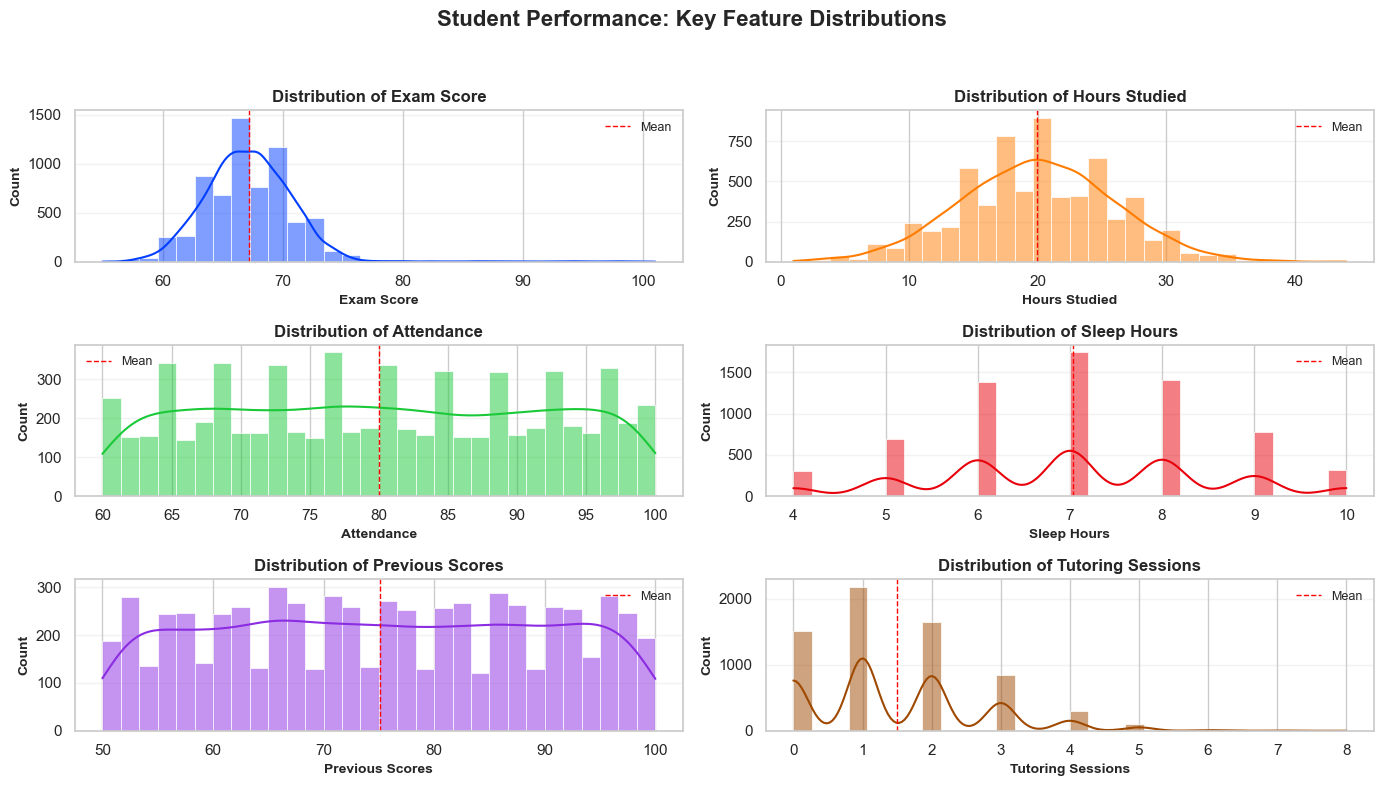

In [180]:

# Visualization: Histograms for key features to understand distributions.

continuous_for_plots = [col for col in ["exam_score"] + numeric_features if col in df_student.columns]
plot_columns = continuous_for_plots[:6]
ncols = 2
nrows = math.ceil(len(plot_columns) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 8))
axes = axes.flatten()
palette = sns.color_palette("bright", n_colors=len(plot_columns))

for ax, column, color in zip(axes, plot_columns, palette):
    data = df_student[column].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax, color=color, edgecolor="white", linewidth=0.5)

    # Mean reference line
    ax.axvline(data.mean(), color="#FF0404", linestyle="--", linewidth=1, label="Mean")
    ax.set_title(f"Distribution of {column.replace('_', ' ').title()}", fontsize=12, weight="bold")
    ax.set_xlabel(column.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_ylabel("Count", fontsize=10, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False, fontsize=9)

# Turn off extra subplots
for ax in axes[len(plot_columns):]:
    ax.axis("off")

fig.suptitle("Student Performance: Key Feature Distributions", fontsize=16, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("./../images/spfc_features_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


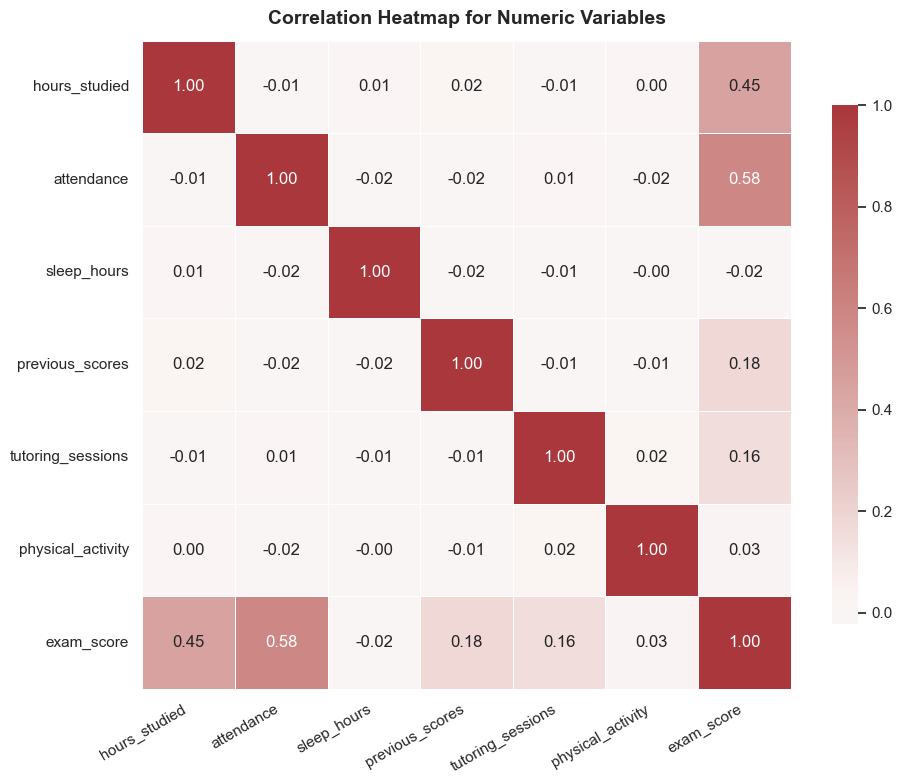

In [181]:

# Plot numeric correlation heatmap

plt.figure(figsize=(10, 8))
correlation_matrix = df_student.select_dtypes(include=np.number).corr(numeric_only=True)
ax = sns.heatmap(
    correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.8}
)

ax.set_title("Correlation Heatmap for Numeric Variables", fontsize=14, weight="bold", pad=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("./../images/spfc_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


['attendance', 'hours_studied', 'previous_scores', 'tutoring_sessions', 'physical_activity']


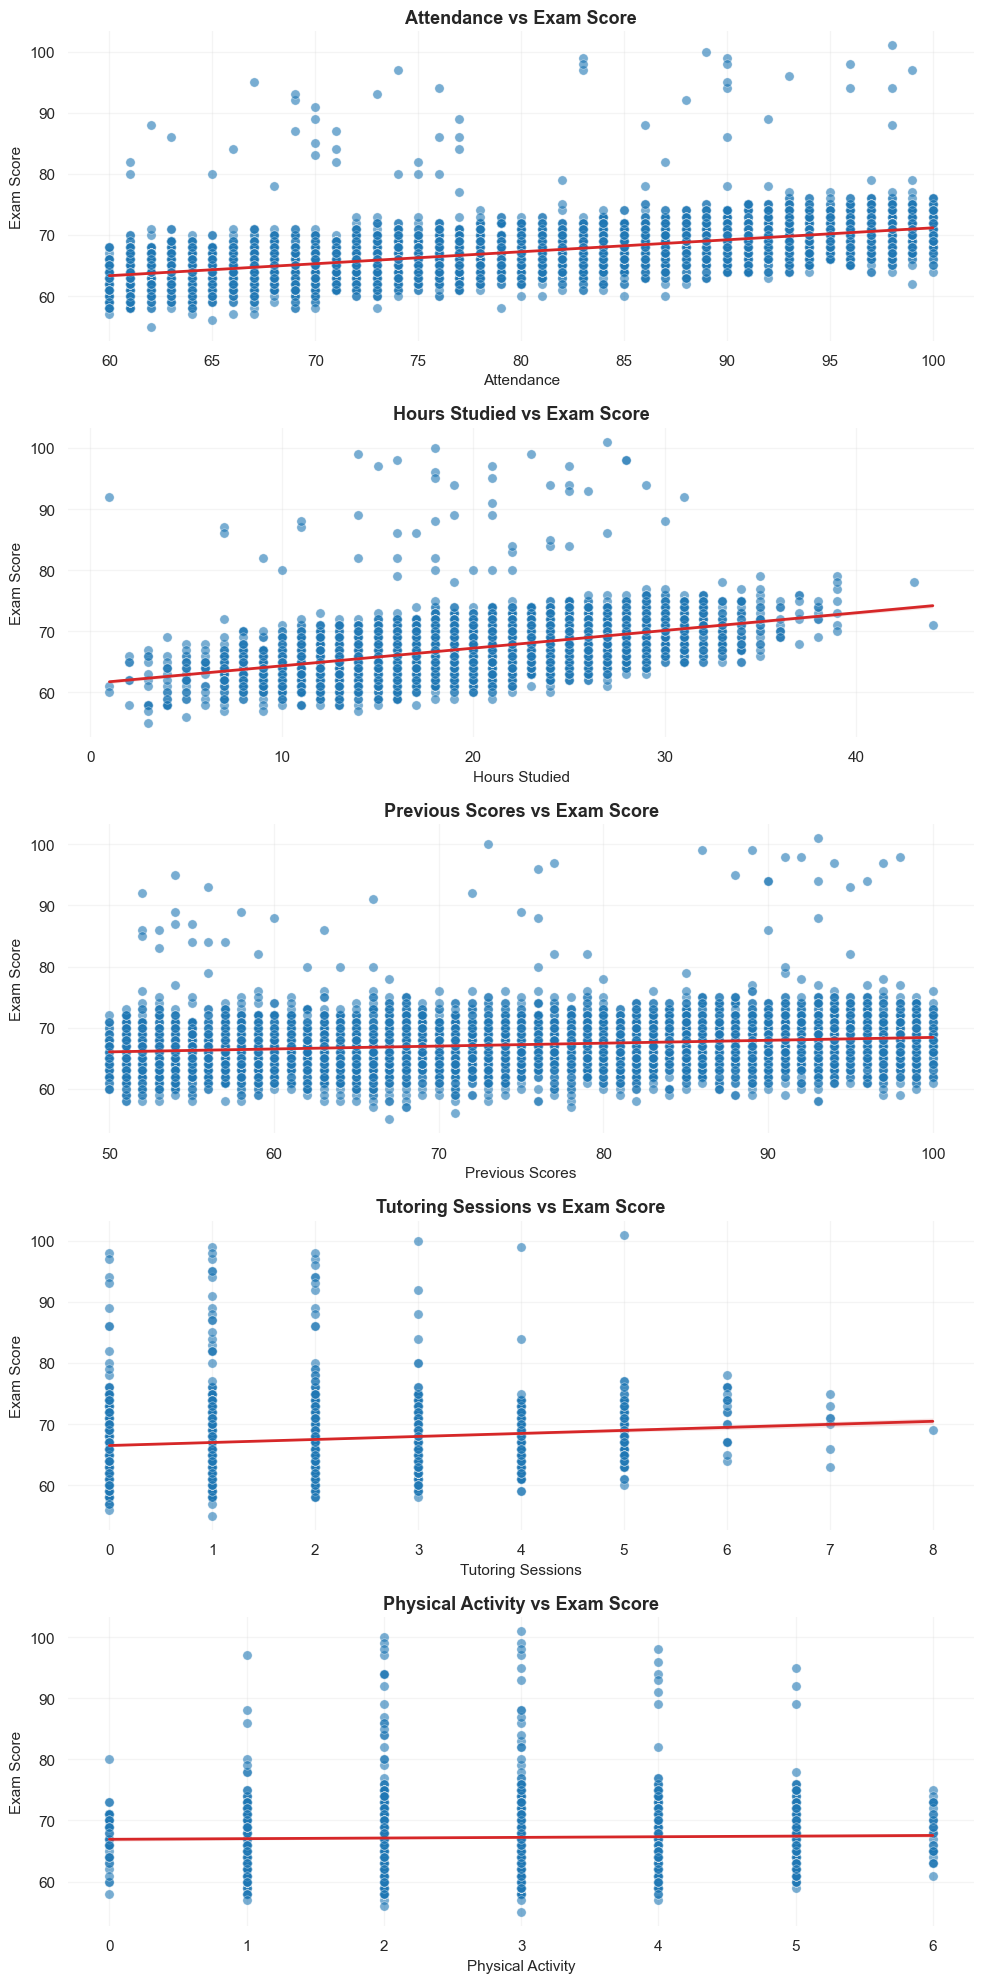

In [182]:

# Plot top numeric relationships with exam_score

top_numeric = correlation_results_df.head(5)["feature"].tolist() if not correlation_results_df.empty else []
print(top_numeric)

if top_numeric:
    fig, axes = plt.subplots(len(top_numeric), 1, figsize=(10, 4 * len(top_numeric)))
    if len(top_numeric) == 1:
        axes = [axes]

    for axis, column in zip(axes, top_numeric):
        sns.scatterplot(data=df_student, x=column, y="exam_score", ax=axis, alpha=0.6, s=45, color="#1f77b4", edgecolor="white", linewidth=0.4)
        sns.regplot(data=df_student, x=column, y="exam_score", scatter=False, ax=axis, color="#d62728", line_kws={"linewidth": 2})

        axis.set_title(f"{column.replace('_', ' ').title()} vs Exam Score", fontsize=13, weight="bold")
        axis.set_xlabel(column.replace("_", " ").title(), fontsize=11)
        axis.set_ylabel("Exam Score", fontsize=11)
        axis.grid(alpha=0.2)

    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.savefig("./../images/spfc_scatterplot_num_features.png", dpi=300, bbox_inches="tight")
    plt.show()



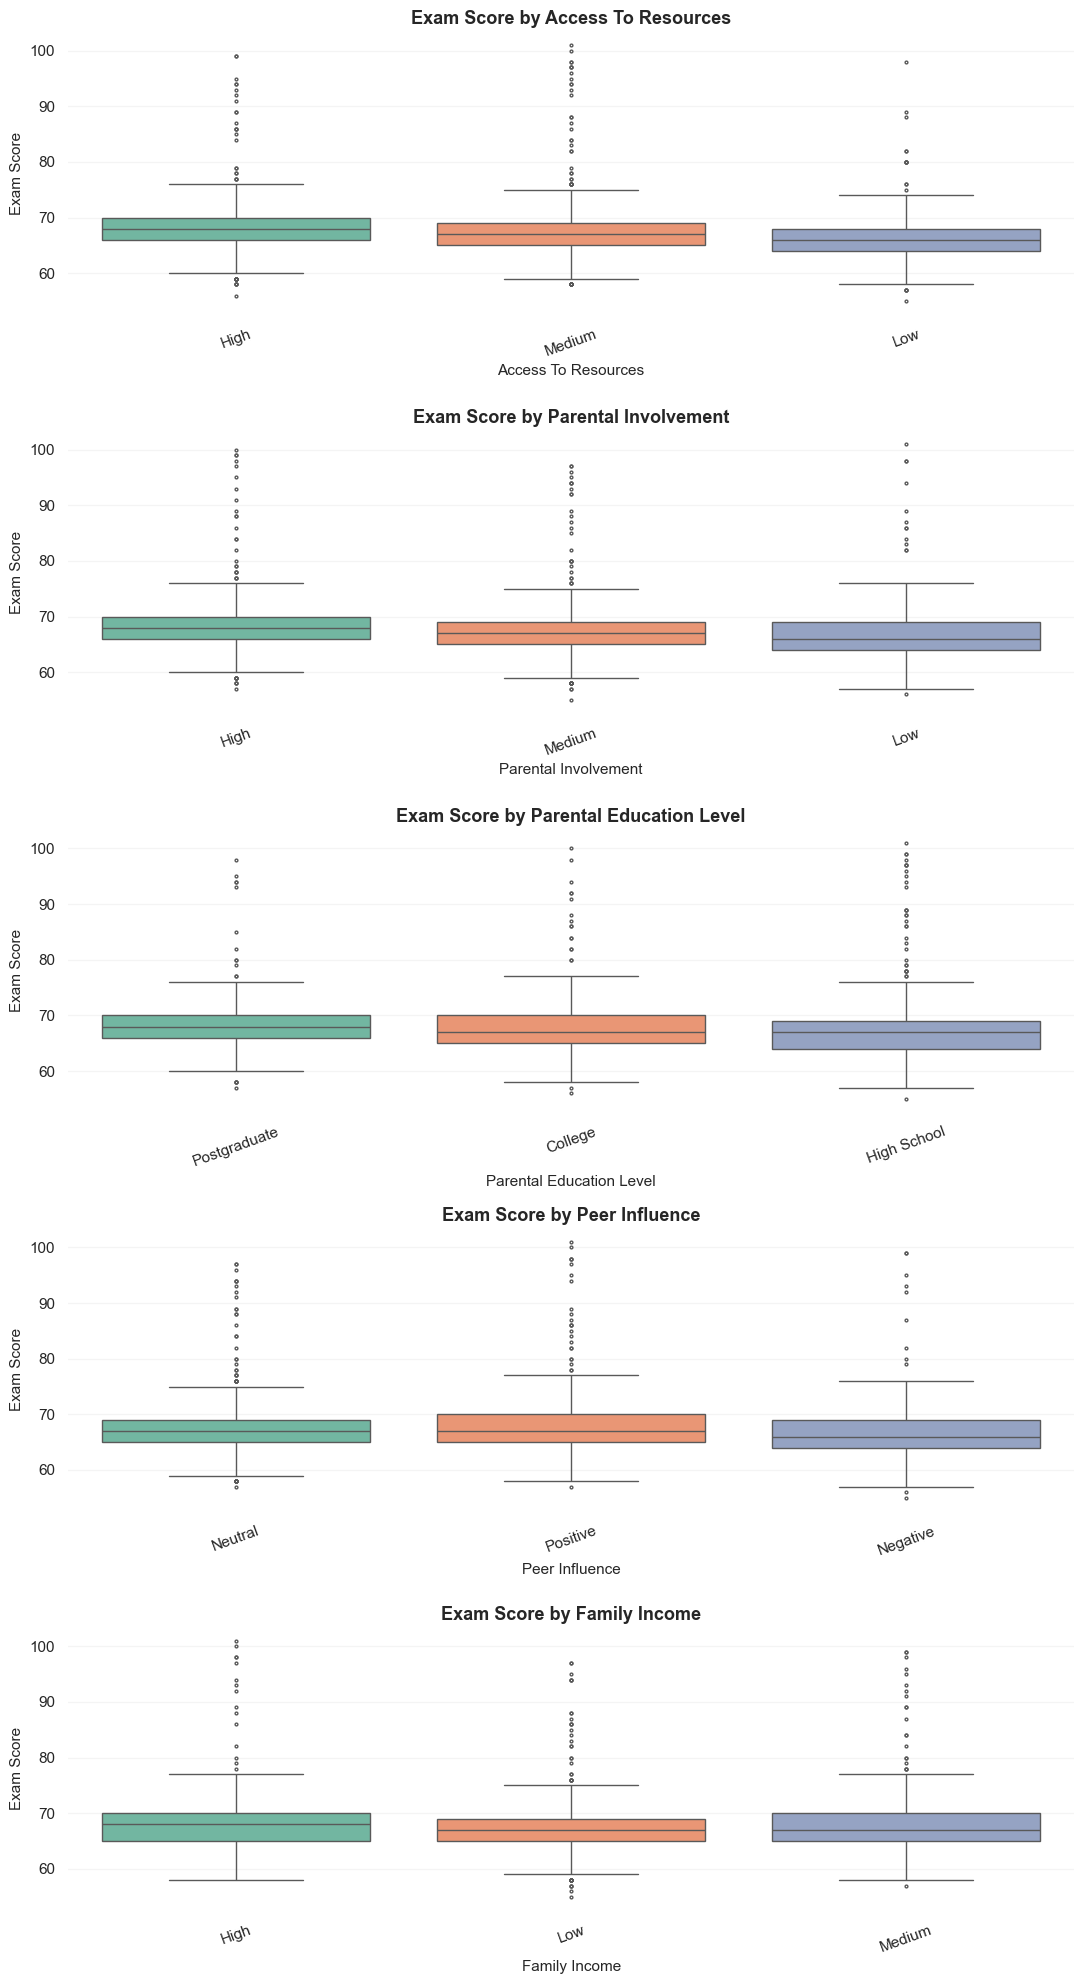

In [183]:

# Compare exam_score across top categorical features.

top_categories = category_corr_results_df.head(5)["feature"].tolist() if not category_corr_results_df.empty else []

if top_categories:
    fig, axes = plt.subplots(len(top_categories), 1, figsize=(11, 4 * len(top_categories)))
    if len(top_categories) == 1:
        axes = [axes]

    for axis, column in zip(axes, top_categories):
        # Order categories by median score for readability
        order = (df_student.groupby(column)["exam_score"].median().sort_values(ascending=False).index)
        sns.boxplot(data=df_student,  x=column, y="exam_score", ax=axis, order=order, palette="Set2", fliersize=2, linewidth=1)

        axis.set_title(f"Exam Score by {column.replace('_', ' ').title()}", fontsize=13, weight="bold")
        axis.set_xlabel(column.replace("_", " ").title(), fontsize=11)
        axis.set_ylabel("Exam Score", fontsize=11)
        axis.grid(axis="y", alpha=0.2)
        axis.tick_params(axis="x", rotation=20)

    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.savefig("./../images/spfc_boxplot_category_features.png", dpi=300, bbox_inches="tight")
    plt.show()


## EDA Conclusion

- Attendance (≈58%) and Hours_Studied (≈45%) dominate: improving presence and focused study time should yield the largest score gains.
- Prior achievement (Previous_Scores ≈18%) and Tutoring_Sessions (≈16%) show secondary influence—prioritize extra help and progress checks for students who are behind.
- Physical_Activity and Sleep_Hours hover near zero, suggesting little direct linear effect on exam scores in this dataset; keep healthy habits, but expect limited score impact without other supports.
- Cross-links among inputs are near zero, so these levers can be adjusted independently.

Actionable focus: boost attendance and structured study time first; pair with tutoring for at‑risk students, using prior scores to flag who needs support.


## 6. Modeling strategy

### Target
`exam_score`

### Train-test split
The dataset is split into training and testing partitions so model selection happens on the training data, while the test set is reserved for final evaluation.

### Model set
Trained a set of 7 baseline models and then applied Hyperparameter Tuning with GridSearchCV. The pipeline automatically selected the top three models; after baseline execution, by lowest MAE for tuning. Retrained them, and then programmatically chose the final best model—no manual selection required.

- LinearRegression
- Ridge
- RandomForestRegressor
- GradientBoostingRegressor
- Lasso
- KNeighborsRegressor
- HistGradientBoostingRegressor

### Validation design
7-fold cross-validation is used on the training data.


In [184]:

# Build preprocessing pipelines and split data into train/test sets.

X = df_student.drop(columns=["exam_score"])
y = df_student["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_preprocessor, numeric_columns),
    ("cat", categorical_preprocessor, categorical_columns),
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)


In [185]:

# Cross-validate multiple baseline regression models.

models = {
    "linear_regression": LinearRegression(),
    "ridge": Ridge(),
    "random_forest": RandomForestRegressor(),
    "gradient_boosting": GradientBoostingRegressor(),
    "lasso": Lasso(),
    "knn_regressor": KNeighborsRegressor(),
    "hgbr_regressor": HistGradientBoostingRegressor()
}

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cv_results = []
trained_pipelines = {}
for model_name, estimator in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", estimator)])
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=None,
        return_train_score=False,
    )
    trained_pipelines[model_name] = pipeline
    cv_results.append({
        "model": model_name,
        "cv_mae": -scores["test_mae"].mean(),
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_r2": scores["test_r2"].mean(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_mae")
cv_results_df


,model,cv_mae,cv_rmse,cv_r2
1,ridge,0.51,2.09,0.72
0,linear_regression,0.51,2.09,0.72
3,gradient_boosting,0.86,2.23,0.68
6,hgbr_regressor,0.88,2.24,0.67
2,random_forest,1.19,2.44,0.61
4,lasso,1.45,2.60,0.56
5,knn_regressor,1.53,2.75,0.51


### Baseline interpretation

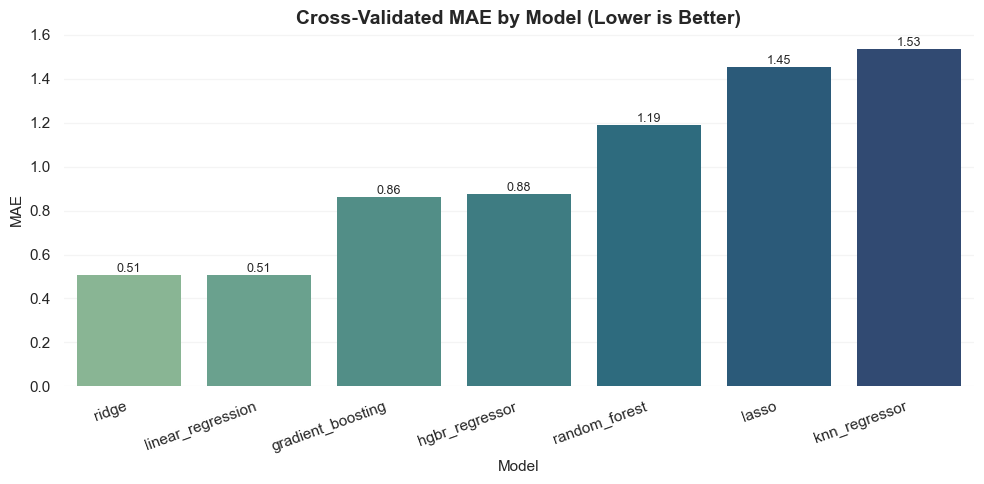

In [186]:

# CVisualize cross-validated MAE by model.

plot_df = cv_results_df.sort_values("cv_mae")
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_df, x="model", y="cv_mae", palette="crest", edgecolor="none")

ax.set_title("Cross-Validated MAE by Model (Lower is Better)", fontsize=14, weight="bold")
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("MAE", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.grid(axis="y", alpha=0.2)

# Add value labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom", fontsize=9)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("./../images/spfc_best_performing_visual.png", dpi=300, bbox_inches="tight")
plt.show()



## 7. Hyperparameter tuning with GridSearchCV

The two strongest non-baseline models are tuned using grid search.
MAE remains the primary selection metric.


In [187]:

# Automatically select tope 3 baseline models to run GridSearchCV hyperparameter models.

model_specs = {
    # Ridge: tune regularization strength and solver settings.
    "ridge": {
        "estimator": Ridge(random_state=42),
        "param_grid": {
            "model__alpha": [0.1, 1.0, 10.0, 25.0, 50.0],
            "model__solver": ["auto", "sag", "saga"],
            "model__tol": [1e-3, 1e-4],
        }
    },
    # GradientBoosting: tune trees, learning rate, and regularization to balance fit vs overfitting.
    "gradient_boosting": {
        "estimator": GradientBoostingRegressor(random_state=42),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3],
            "model__subsample": [0.8, 1.0],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 5],
            "model__max_features": [None, "sqrt"],
        },
    },
    "linear_regression": {
        "estimator": LinearRegression(),
        "param_grid": {},
    },
    # Lasso: tune sparsity strength and optimization settings.
    "lasso": {
            "estimator": Lasso(random_state=42, max_iter=10000),
            "param_grid": {
            "model__alpha": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
            "model__max_iter": [3000, 5000, 8000],
            "model__tol": [1e-3, 1e-4],
            "model__selection": ["cyclic", "random"],
        },
    },
    # KNN: tune neighbors, distance weighting, and metric.
    "knn_regressor": {
        "estimator": KNeighborsRegressor(),
        "param_grid": {
            "model__n_neighbors": [3, 5, 7, 11],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    },
    # RandomForest: tune tree count, depth, and split controls to manage overfitting.
    "random_forest": {
        "estimator": RandomForestRegressor(random_state=42),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 16],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2],
            "model__max_features": ["sqrt", 0.3]
        },
    },
    # HistGradientBoosting: tune learning rate, trees, and regularization for stable boosting.
    "hgbr_regressor": {
        "estimator": HistGradientBoostingRegressor(random_state=42),
        "param_grid": {
            "model__learning_rate": [0.05, 0.1],
            "model__max_iter": [200, 400],
            "model__max_depth": [3, None],
            "model__min_samples_leaf": [10, 20],
            "model__l2_regularization": [0.0, 1e-2],
        },
    },
}

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

# pick top-3 from cv_results_df, all hyper parameters are configured for all 7
top3_names = cv_results_df.nsmallest(3, "cv_mae")["model"].tolist()
print("Running Top-3 Base Models to train the data with Hyper Parameters:", top3_names)

results = []
best_models = {}
best_grids = {}

for name in top3_names:
    spec = model_specs[name]
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", spec["estimator"])
    ])
    grid = GridSearchCV(
        pipeline,
        spec["param_grid"],
        cv=cv,
        scoring=scoring,
        refit="mae",
        n_jobs=None
    )
    grid.fit(X_train, y_train)

    best_grids[name] = grid
    best_models[name] = grid.best_estimator_
    idx = grid.best_index_
    results.append({
        "model": name,
        "cv_mae": -grid.cv_results_["mean_test_mae"][idx],
        "cv_rmse": -grid.cv_results_["mean_test_rmse"][idx],
        "cv_r2": grid.cv_results_["mean_test_r2"][idx],
        "best_params": grid.best_params_
    })
    # print(f"Name: {name}, CV_MAE: {results[-1]['cv_mae']}, CV_RMSE: {results[-1]['cv_rmse']}, CV_R2: {results[-1]['cv_r2']}, Best Params: {grid.best_params_}")

results_df = pd.DataFrame(results).sort_values(
    by=["cv_mae"]
)
results_df

Running Top-3 Base Models to train the data with Hyper Parameters: ['ridge', 'linear_regression', 'gradient_boosting']


,model,cv_mae,cv_rmse,cv_r2,best_params
0,ridge,0.51,2.09,0.72,"{'model__alpha': 10.0, 'model__solver': 'auto'..."
1,linear_regression,0.51,2.09,0.72,{}
2,gradient_boosting,0.64,2.13,0.70,"{'model__learning_rate': 0.1, 'model__max_dept..."


## 8. Final model evaluation

In [188]:

# Select best tuned model, export a pickle file it into ./web folder along with the timestamp in its filename, and compute test metrics.
# Note: A .pkl (pickle) file is a binary file used to serialize and save Python objects, most commonly trained models. 
# Its used in User Interface later, without retraining, preserving its learned parameters and state to predict the Exam_Score.

final_model_name, final_grid = max(best_grids.items(), key=lambda kv: kv[1].best_score_)
final_model = final_grid.best_estimator_

print("Selected final model:", final_model_name)

final_predictions = final_model.predict(X_test)
ts = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%SUTC")
filename = f"./../web/{final_model_name}_spf_{ts}.pkl"

# persist the best model
joblib.dump(final_model, filename)

mae = mean_absolute_error(y_test, final_predictions)
rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
r2 = r2_score(y_test, final_predictions)

evaluation_summary = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [mae, rmse, r2],
})
evaluation_summary


Selected final model: ridge


,metric,value
0,MAE,0.45
1,RMSE,1.80
2,R2,0.77


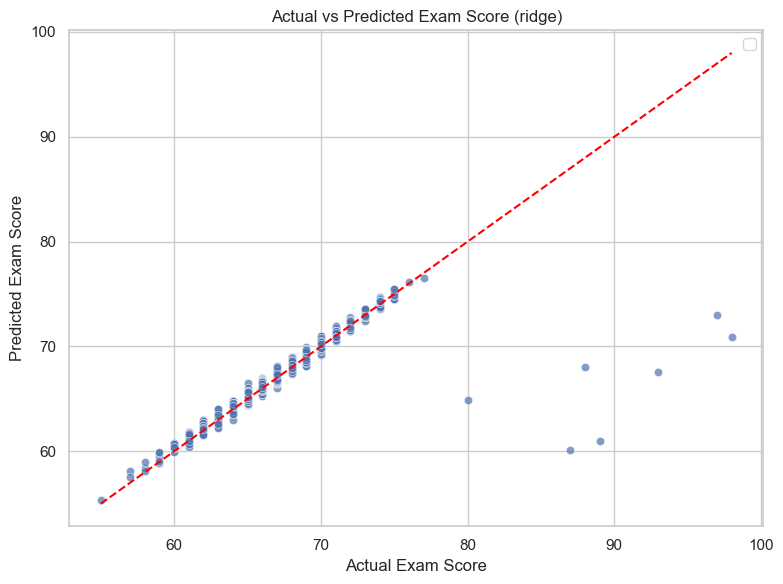

In [189]:
# Visualize actual vs predicted exam scores.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=final_predictions, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()], 
    [y_test.min(), y_test.max()],
    linestyle="--", color="red",
)
plt.title(f"Actual vs Predicted Exam Score ({final_model_name})")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.legend()
plt.tight_layout()
plt.savefig("./../images/spfc_predicted_Vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Model interpretation

In [190]:

# Permutation importance helps explain which features matter most to the selected model.

perm_result = permutation_importance(final_grid.best_estimator_, X_test, y_test, n_repeats=10, random_state=42, scoring="neg_mean_absolute_error",)

feature_names = X_test.columns
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

# Top 10 important features
importance_df.head(10)

,feature,importance_mean,importance_std
1,attendance,2.34,0.03
0,hours_studied,1.70,0.02
3,access_to_resources,0.55,0.01
6,previous_scores,0.54,0.01
2,parental_involvement,0.52,0.01
9,tutoring_sessions,0.44,0.01
10,family_income,0.21,0.01
16,parental_education_level,0.21,0.01
13,peer_influence,0.21,0.01
7,motivation_level,0.20,0.00


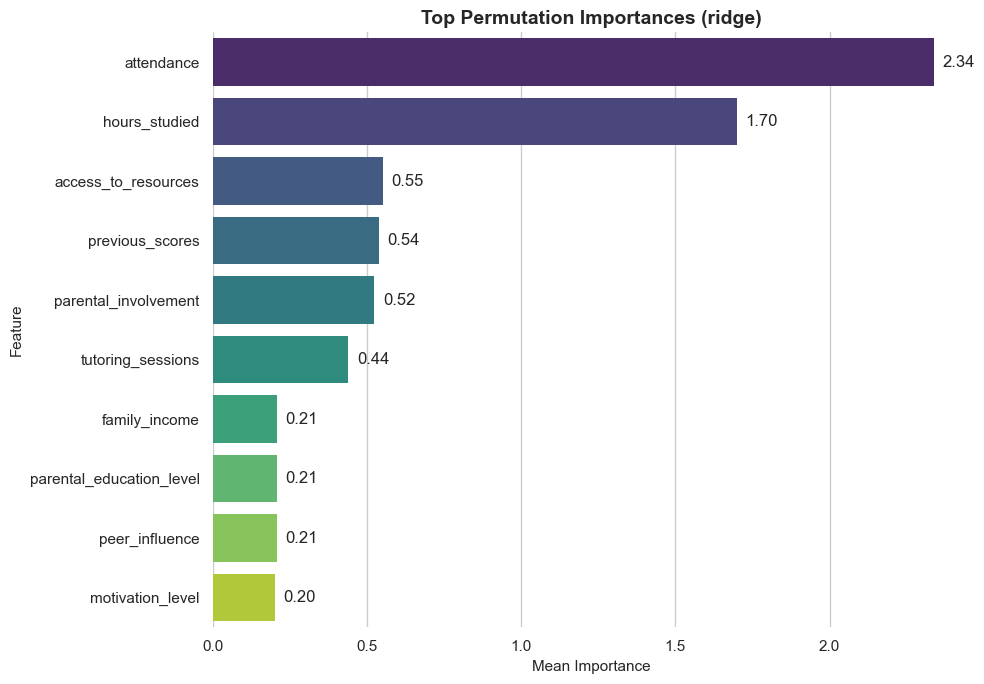

In [191]:

# Plot the top 10 feature importances.

plot_df = importance_df.nlargest(10, "importance_mean").sort_values("importance_mean", ascending=False)

plt.figure(figsize=(10, 7))
ax = sns.barplot(data=plot_df, x="importance_mean", y="feature", palette="viridis", edgecolor="none")

ax.set_title(f"Top Permutation Importances ({final_model_name})", fontsize=14, weight="bold")
ax.set_xlabel("Mean Importance", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        xytext=(6, 0),
        textcoords="offset points",
        va="center"
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("./../images/spfc_plot_imp_features.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Findings
- improve attendance support
- target study-skills coaching where hours studied are low
- increase tutoring access for lower-performing segments
- investigate whether resource access or teacher quality is associated with meaningful score gaps
- encourage parent's involvement
- offer tutoring session, especially to those who needs drastic improvement
